In [1]:
# import os
# import imageio
# import numpy as np
# from skimage.transform import resize

# data_folder = 'D:/CT/CT_small'
# output_file = 'output_small_data.npz'
# target_slices = 224

# # すべてのフォルダを列挙
# folder_list = os.listdir(data_folder)

# # 3次元データを格納するリストを作成
# all_data = []

# for folder_name in folder_list:
#     folder_path = os.path.join(data_folder, folder_name)
#     image_list = os.listdir(folder_path)
#     image_list.sort()  # 画像をソートして正しい順序で読み込む

#     volume_slices = []
#     for image_name in image_list[:target_slices]:  # 最初の224枚を読み込む
#         image_path = os.path.join(folder_path, image_name)
#         img = imageio.imread(image_path)
#         volume_slices.append(img)

#     # 画像を224枚にリサイズ
#     resized_slices = [resize(img_data, (224, 224)) for img_data in volume_slices]

#     # 3次元データにまとめる
#     volume_data = np.stack(resized_slices, axis=-1)

#     # 3次元データをリストに追加
#     all_data.append(volume_data)

# # リストをNumPy配列に変換して保存
# # np.savez(output_file, *all_data)
# np.savez(output_file, train = all_data)

In [2]:
# import numpy as np

# # ファイルを読み込む
# data = np.load('output_small_data.npz')

# # ファイル内のキーを取得
# keys = data.files

# # 各キーごとのデータを表示
# for key in keys:
#     print(f"Key: {key}")
#     print(data[key])  # データを表示する

In [3]:
import numpy as np
import pydicom
import os

# DICOMファイルのパス
folder_path = r"D:\CT\CT_Train"

# すべてのDICOMファイルを読み込む
dicom_files = sorted([os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.dcm')])

# 3次元ボリュームにデータを結合するためのリストを作成
data_list = []

# すべてのDICOMファイルを処理
for file_path in dicom_files:
    # DICOMファイルの読み込み
    dicom_data = pydicom.dcmread(file_path)
    
    # DICOMデータから画像データを取得してリストに追加
    data_list.append(dicom_data.pixel_array.astype(float))

# 3次元に圧縮
compressed_data = np.stack(data_list, axis=-1)

# データの正規化
min_val = np.min(compressed_data)
max_val = np.max(compressed_data)
normalized_data = (compressed_data - min_val) / (max_val - min_val)

# データの保存
np.savez("output_small_data.npz", Train=normalized_data)

In [4]:
import numpy as np

# ファイルを読み込む
data = np.load('output_small_data.npz')

# ファイル内のキーを取得
keys = data.files

# 各キーごとのデータを表示
for key in keys:
    print(f"Key: {key}")
    print(data[key])  # データを表示する

Key: Train
[[[[0.03526012 0.03526012 0.03526012 ... 0.03526012 0.03526012
    0.03526012]
   [0.03526012 0.03526012 0.03526012 ... 0.03526012 0.03526012
    0.03526012]
   [0.03526012 0.03526012 0.03526012 ... 0.03526012 0.03526012
    0.03526012]
   ...
   [0.03526012 0.03526012 0.03526012 ... 0.03526012 0.03526012
    0.03526012]
   [0.03526012 0.03526012 0.03526012 ... 0.03526012 0.03526012
    0.03526012]
   [0.03526012 0.03526012 0.03526012 ... 0.03526012 0.03526012
    0.03526012]]

  [[0.03526012 0.03526012 0.03526012 ... 0.03526012 0.03526012
    0.03526012]
   [0.03526012 0.03526012 0.03526012 ... 0.03526012 0.03526012
    0.03526012]
   [0.03526012 0.03526012 0.03526012 ... 0.03526012 0.03526012
    0.03526012]
   ...
   [0.03526012 0.03526012 0.03526012 ... 0.03526012 0.03526012
    0.03526012]
   [0.03526012 0.03526012 0.03526012 ... 0.03526012 0.03526012
    0.03526012]
   [0.03526012 0.03526012 0.03526012 ... 0.03526012 0.03526012
    0.03526012]]

  [[0.03526012 0.035260

['Train']


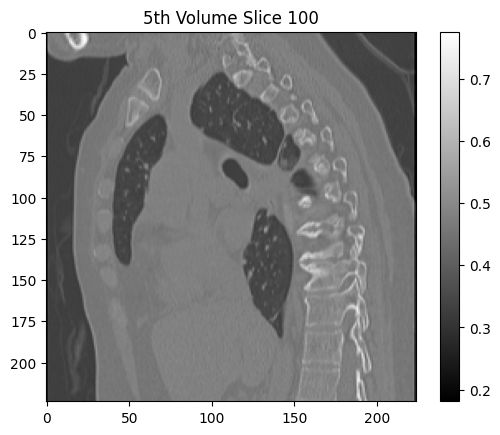

In [6]:
import numpy as np

# NPZファイルからデータを読み込む
data = np.load("output_small_data.npz")

# NPZファイル内のデータキーを確認
keys = list(data.keys())
print(keys)  # キーのリストを表示

# 5つ目のボリュームデータを取得
volume = data[keys[0]][:, :, :, 4]  # 5つ目のボリュームデータを取得

# ボリュームデータを表示（例えば、matplotlibを使用して）
import matplotlib.pyplot as plt

# 任意のスライスを表示する例
slice_index = 100  # スライスのインデックス
plt.imshow(volume[:, :, slice_index], cmap='gray')
plt.title('5th Volume Slice {}'.format(slice_index))
plt.colorbar()
plt.show()


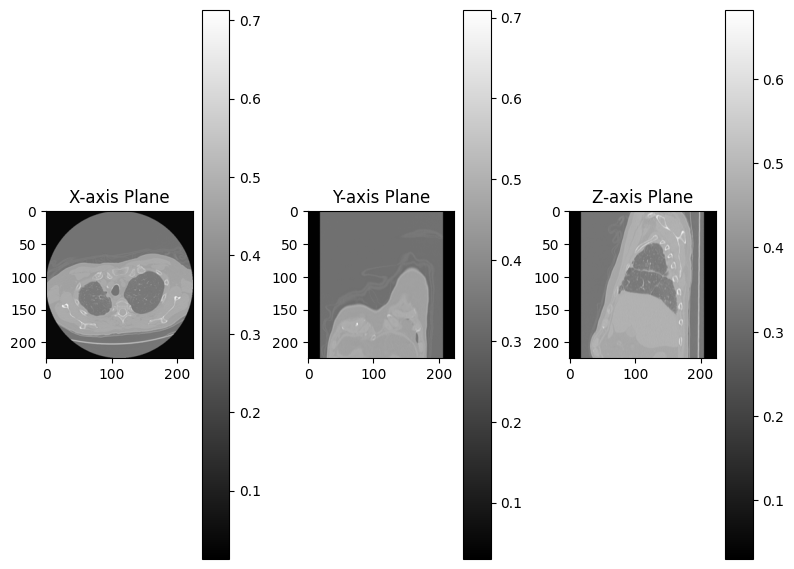

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# NPZファイルからデータを読み込む
data = np.load("output_small_data.npz")

# 5つ目のボリュームデータを取得
volume = data['Train'][:, :, :, 1]  # 5つ目のボリュームデータを取得

# x軸方向からの断面を表示
plt.figure(figsize=(8, 6))
plt.subplot(131)
plt.imshow(volume[50, :, :], cmap='gray')
plt.title('X-axis Plane')
plt.colorbar()

# y軸方向からの断面を表示
plt.subplot(132)
plt.imshow(volume[:, 50, :], cmap='gray')
plt.title('Y-axis Plane')
plt.colorbar()

# z軸方向からの断面を表示
plt.subplot(133)
plt.imshow(volume[:, :, 50], cmap='gray')
plt.title('Z-axis Plane')
plt.colorbar()

plt.tight_layout()
plt.show()


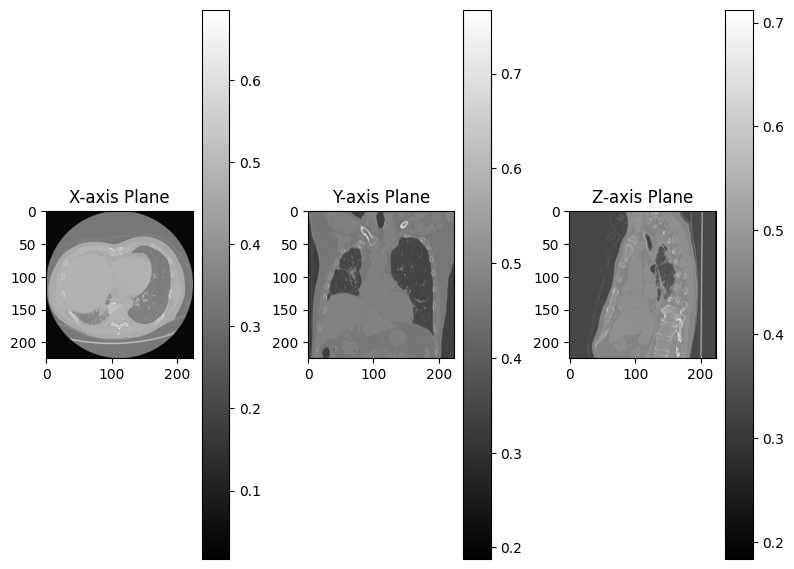

In [11]:
# x軸方向からの断面を表示
plt.figure(figsize=(8, 6))
plt.subplot(131)
plt.imshow(volume[150, :, :], cmap='gray')
plt.title('X-axis Plane')
plt.colorbar()

# y軸方向からの断面を表示
plt.subplot(132)
plt.imshow(volume[:, 100, :], cmap='gray')
plt.title('Y-axis Plane')
plt.colorbar()

# z軸方向からの断面を表示
plt.subplot(133)
plt.imshow(volume[:, :, 100], cmap='gray')
plt.title('Z-axis Plane')
plt.colorbar()

plt.tight_layout()
plt.show()
